In [1]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

c:\Users\Amine\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
FEATURES = [       # the 10 features — input to the LSTM
    "return",
    "lag1",
    "lag5",
    "lag10",
    "ma10",
    "ma50",
    'price_vs_ma50',
    'high_low_range',
    "volatility5",
    "volatility10",
    "volatility20",
    "volatility60",
    'vol_ratio',
    "rsi",
    "macd",
    'volume_change',
    "volume_ratio"
]
TARGET = "volatility20"   # what we predict

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE   # lenovo legion with RTX 4060 ^_^

device(type='cuda')

In [4]:
class StockDataset(Dataset):
    """
    Simple PyTorch Dataset wrapper around our numpy arrays.
    Converts them to float32 tensors and moves to device.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
class StockLSTM(nn.Module):
    """
    LSTM model for stock return prediction.
 
    Architecture:
        Input  → LSTM layers → Dropout → Linear → Output
 
    Input shape:  (batch_size, W, n_features)
    Output shape: (batch_size, 1)
    """
    def __init__(self, n_features: int, hidden_size: int, num_layers: int, dropout: float):
        super(StockLSTM, self).__init__()
 
        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,  # dropout only between layers
            batch_first  = True    # input shape: (batch, seq, features)
        )
 
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        # x shape: (batch_size, W, n_features)
 
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch_size, W, hidden_size)
 
        # take only the last timestep's output
        # because we want to predict the next day after the sequence ends
        last_out = lstm_out[:, -1, :]
        # last_out shape: (batch_size, hidden_size)
 
        out = self.dropout(last_out)
        out = self.linear(out)
        out = torch.relu(out)
        # out shape: (batch_size, 1)
 
        return out.squeeze(1)   # shape: (batch_size,)

In [6]:
def quantile_loss(preds, target, quantile=0.63):
    """
    Calculate the pinball/quantile loss.
    quantile: float between 0 and 1 (e.g., 0.9 for the 90th percentile).
    """
    errors = target - preds
    loss = torch.max((quantile - 1) * errors, quantile * errors)
    return loss.mean()

In [7]:
from functions import make_windows, apply_scaler, fit_scaler

def train_trial(trial, tr_data, val_data, n_features, epochs):
    """
    Trains one model configuration suggested by Optuna.
    Returns best validation loss.
    """

    # ── suggest hyperparameters
    hidden_size   = trial.suggest_categorical('hidden_size',  [64, 128, 192, 256])
    num_layers    = trial.suggest_int('num_layers',           1, 4)
    dropout       = trial.suggest_float('dropout',            0.1, 0.5)
    learning_rate = trial.suggest_float('lr',                 1e-4, 5e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size',   [64, 128, 192, 256])
    patience      = trial.suggest_int('patience',             10, 25)
    W = trial.suggest_categorical('W',  [30, 40, 50, 60, 70, 80, 90, 100, 110])
    # quantile =  trial.suggest_float('quantile', 0.2, 0.9)

    X_tr,  y_tr  = make_windows(tr_data,  W, features=FEATURES, target=TARGET)
    X_val, y_val  = make_windows(val_data, W, features=FEATURES, target=TARGET)
    scaler = fit_scaler(X_tr)
    X_tr_scaled  = apply_scaler(X_tr,  scaler)
    X_val_scaled   = apply_scaler(X_val, scaler)
 
    # ── dataloaders
    train_loader = DataLoader(StockDataset(X_tr_scaled,  y_tr),  batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(StockDataset(X_val_scaled, y_val), batch_size=batch_size, shuffle=False)
 
    # ── model
    model = StockLSTM(n_features, hidden_size, num_layers, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    # criterion = nn.MSELoss()

    best_val_loss    = float('inf')
    patience_counter = 0
 
    for epoch in range(1, epochs + 1):
 
        # train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = quantile_loss(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
        # validate
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_losses.append(quantile_loss(model(X_batch), y_batch).item())
 
        val_loss = np.mean(val_losses)
        scheduler.step(val_loss)
 
        # early stopping
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
 
        # Optuna pruning — cuts unpromising trials early
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
 
    return best_val_loss
 
 
# ── Optuna objective ──────────────────────────────────────────────────────────
def make_objective(tr_data, val_data, n_features, epochs):
    def objective(trial):
        return train_trial(trial, tr_data, val_data, n_features, epochs)
    return objective

[*********************100%***********************]  1 of 1 completed
[I 2026-04-07 19:03:33,547] A new study created in memory with name: stock_lstm_tuning


train=3172 rows, test=793 rows, split date=2023-02-07
train=2537 rows, test=635 rows, split date=2020-07-30
Starting Optuna search — 100 trials on cuda


  0%|          | 0/100 [00:00<?, ?it/s]

number of instances : 2507
number of instances : 605


Best trial: 0. Best value: 0.00111339:   1%|          | 1/100 [00:13<22:18, 13.52s/it]

...

[I 2026-04-07 19:32:48,697] Trial 97 pruned. 
number of instances : 2437
number of instances : 535


Best trial: 88. Best value: 0.000346951:  99%|█████████▉| 99/100 [29:22<00:09,  9.82s/it]

[I 2026-04-07 19:32:55,929] Trial 98 pruned. 
number of instances : 2447
number of instances : 545


Best trial: 88. Best value: 0.000346951: 100%|██████████| 100/100 [29:32<00:00, 17.73s/it]


[I 2026-04-07 19:33:06,170] Trial 99 pruned. 

Best trial:
  Val loss : 0.000347
  Params   :
    hidden_size          : 128
    num_layers           : 1
    dropout              : 0.29255451180333386
    lr                   : 0.0011482784997348093
    batch_size           : 64
    patience             : 17
    W                    : 90

Study saved to models/optuna_study.pkl
Plotting skipped: [Errno 2] No such file or directory: 'models/optuna_results.png'


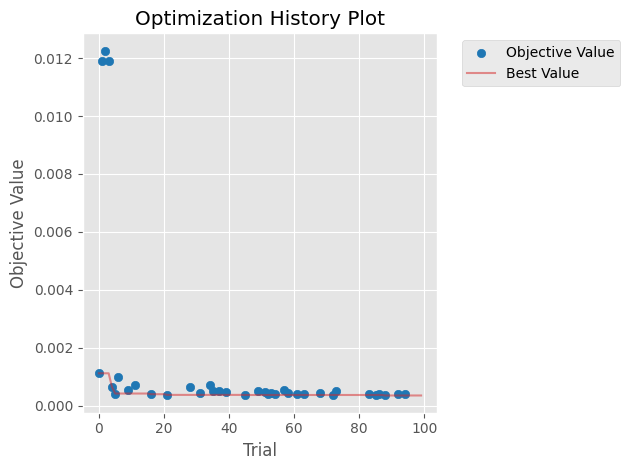

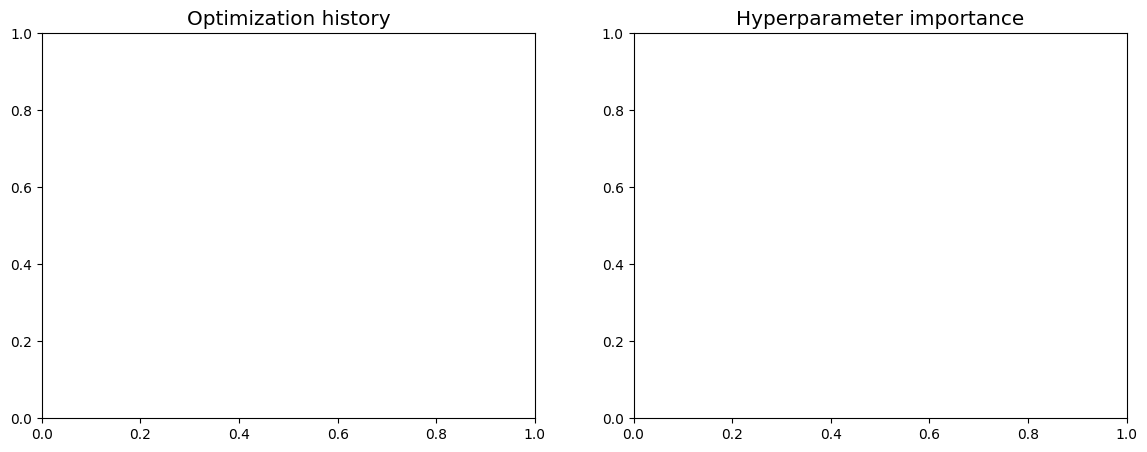

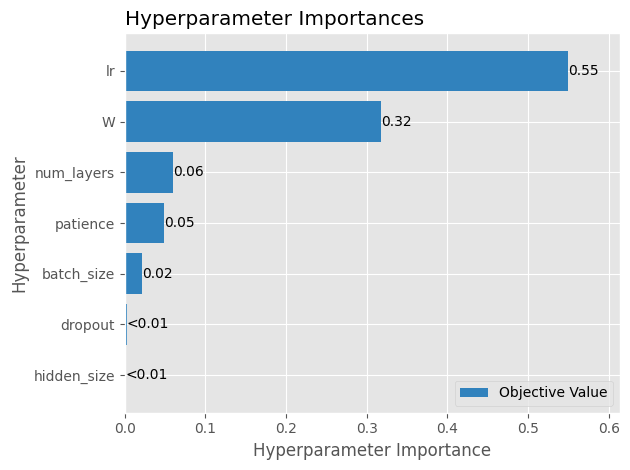

In [8]:
import joblib
from functions import compute_features, load_ticker, split_data

TICKER = "AAPL"
PERIOD    = "16y"
TRAIN_PCT = 0.8 

data = load_ticker(TICKER, PERIOD)
train_data, _ = split_data(data, TRAIN_PCT)
tr_data, val_data = split_data(train_data, TRAIN_PCT)

# ── run Optuna study

N_TRIALS  = 100     # number of Optuna trials — increase to 100 if you have time
EPOCHS    = 100     # max epochs per trial — early stopping will cut most short
sampler = TPESampler(seed=42)      # TPE = Tree-structured Parzen Estimator
                                       # smarter than random search
n_features = len(FEATURES)

pruner  = MedianPruner(
    n_startup_trials  = 5,         # don't prune first 5 trials
    n_warmup_steps    = 10,        # don't prune first 10 epochs of each trial
)
 
study = optuna.create_study(
    direction = 'minimize',        # minimize validation loss
    sampler   = sampler,
    pruner    = pruner,
    study_name= 'stock_lstm_tuning'
)
 
print(f"Starting Optuna search — {N_TRIALS} trials on {DEVICE}")
print("=" * 60)
 
study.optimize(
    make_objective(tr_data, val_data, n_features, EPOCHS),
    n_trials  = N_TRIALS,
    show_progress_bar = True
)
 
# ── results
print("\n" + "=" * 60)
print("Best trial:")
print(f"  Val loss : {study.best_trial.value:.6f}")
print(f"  Params   :")
for k, v in study.best_trial.params.items():
    print(f"    {k:20s} : {v}")
 
# ── save study
joblib.dump(study, '../models/optuna_study.pkl')
print("\nStudy saved to models/optuna_study.pkl")

# ── plot results
try:
    import matplotlib.pyplot as plt
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plt.sca(axes[0])
    plot_optimization_history(study)
    axes[0].set_title('Optimization history')

    plt.sca(axes[1])
    plot_param_importances(study)
    axes[1].set_title('Hyperparameter importance')

    plt.tight_layout()
    plt.savefig('models/optuna_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plots saved to models/optuna_results.png")
except Exception as e:
    print(f"Plotting skipped: {e}")